In [14]:
# Setup -------------------------------------------------------------------

import pandas as pd
from sklearn.linear_model import LogisticRegression
import sklearn.metrics #import confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [15]:
# Load the iris dataset
from sklearn.datasets import load_iris
iris_data = load_iris()
iris = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
iris['species'] = iris_data.target


In [16]:

# Map species names to the target variable
iris['species'] = iris['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})


In [17]:

# Create the binary target variable 'Species2'
# This is equivalent to the R code: iris$Species2 <- if_else(iris$Species == "setosa", 1, 0)
iris['Species2'] = np.where(iris['species'] == 'setosa', 1, 0)

# The R line `is.factor(iris$Species2)` is for type checking, which isn't necessary here
# as we have a numerical column.


In [18]:

# Fit the logistic regression model
# The R code uses `glm` with `binomial(link = "logit")`, which corresponds to LogisticRegression
lgi_mdl = LogisticRegression() # liblinear is good for small datasets
X = iris[['sepal length (cm)']]
y = iris['Species2']
lgi_mdl.fit(X, y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:

# Summary of the model
# scikit-learn doesn't have a direct `summary` function like R.
# We'll print coefficients and intercept.
print("--- Model Summary ---")
print("Coefficients:", lgi_mdl.coef_[0][0])
print("Intercept:", lgi_mdl.intercept_[0])
print("---------------------\n")


--- Model Summary ---
Coefficients: -3.4584564288174713
Intercept: 18.549614799311275
---------------------



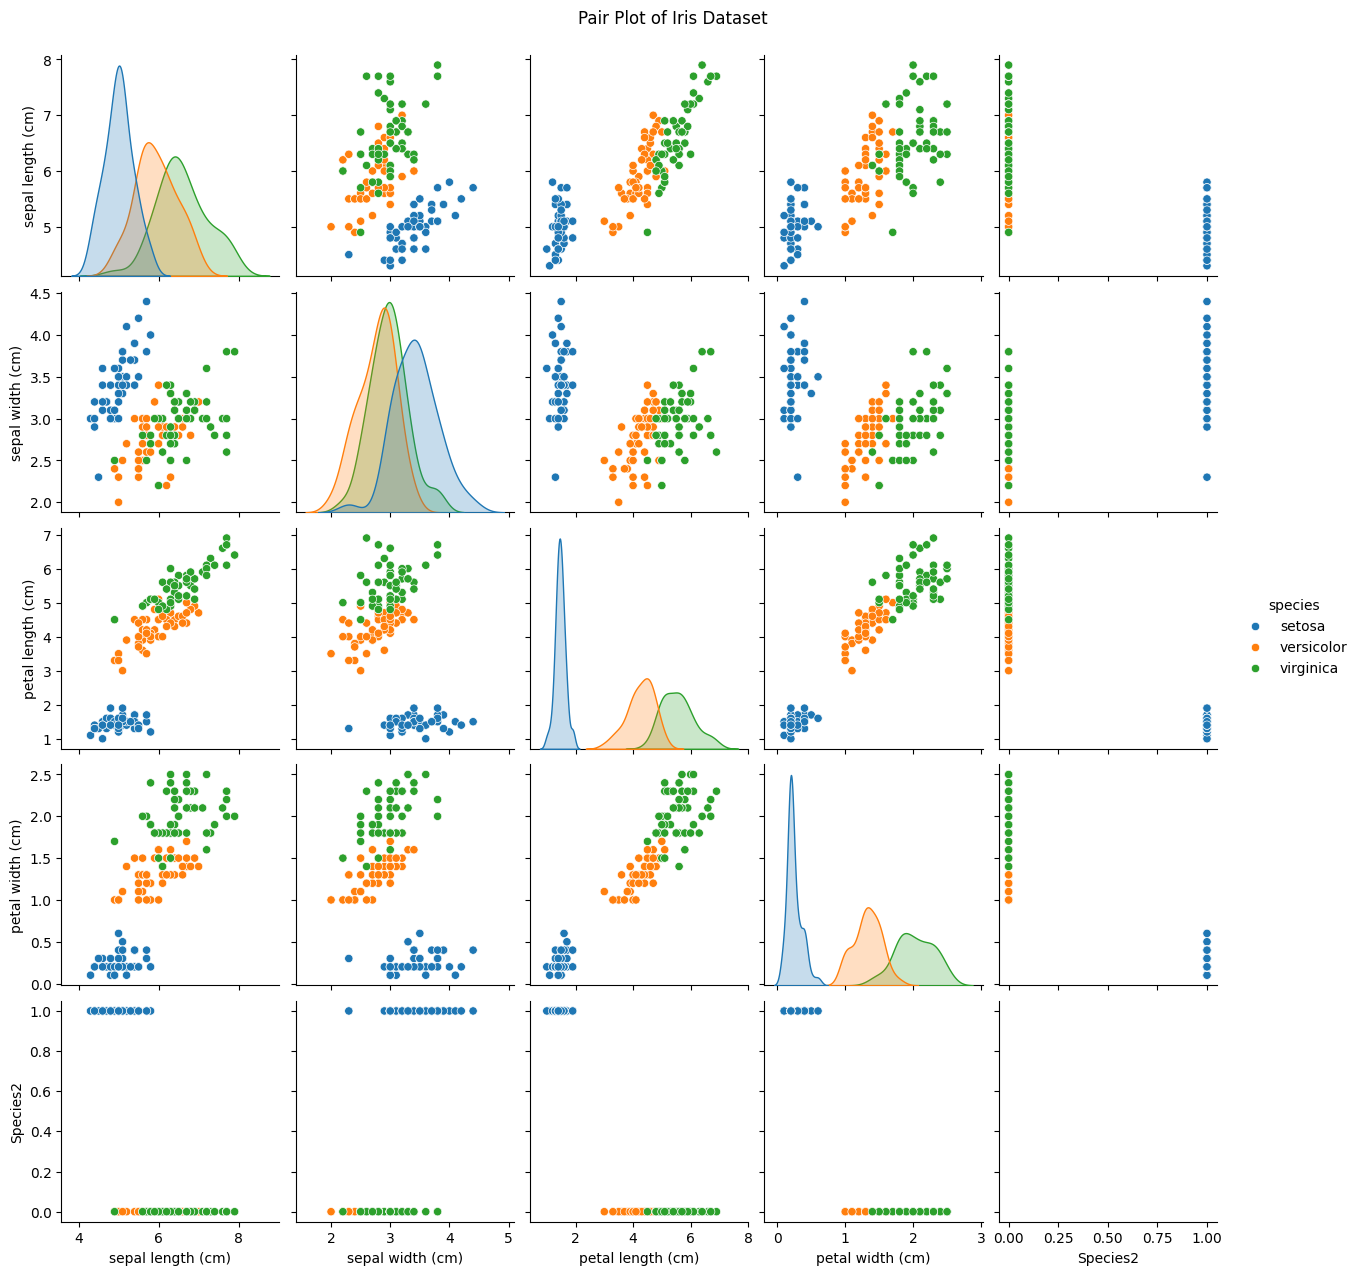

In [20]:
# Plotting the data
# The R plot(iris) is a scatter plot matrix. seaborn's pairplot is a good equivalent.
sns.pairplot(iris, hue='species')
plt.suptitle('Pair Plot of Iris Dataset', y=1.02)
plt.show()

In [21]:
lgi_mdl.predict_proba(X)

array([[2.86695645e-01, 7.13304355e-01],
       [1.67537873e-01, 8.32462127e-01],
       [9.15487521e-02, 9.08451248e-01],
       [6.65635827e-02, 9.33436417e-01],
       [2.21433402e-01, 7.78566598e-01],
       [5.31470821e-01, 4.68529179e-01],
       [6.65635827e-02, 9.33436417e-01],
       [2.21433402e-01, 7.78566598e-01],
       [3.44760338e-02, 9.65523966e-01],
       [1.67537873e-01, 8.32462127e-01],
       [5.31470821e-01, 4.68529179e-01],
       [1.24659826e-01, 8.75340174e-01],
       [1.24659826e-01, 8.75340174e-01],
       [2.46444066e-02, 9.75355593e-01],
       [8.18977086e-01, 1.81022914e-01],
       [7.61983852e-01, 2.38016148e-01],
       [5.31470821e-01, 4.68529179e-01],
       [2.86695645e-01, 7.13304355e-01],
       [7.61983852e-01, 2.38016148e-01],
       [2.86695645e-01, 7.13304355e-01],
       [5.31470821e-01, 4.68529179e-01],
       [2.86695645e-01, 7.13304355e-01],
       [6.65635827e-02, 9.33436417e-01],
       [2.86695645e-01, 7.13304355e-01],
       [1.246598

In [22]:
# Making predictions and creating a confusion matrix
# `predict_proba` gives the probabilities (equivalent to type = "response")
iris['pred_proba'] = lgi_mdl.predict_proba(X)[:, 1]
iris['pred'] = np.where(iris['pred_proba'] > 0.5, 1, 0)

In [23]:
# Create Confusion Matrix
cm = sklearn.metrics.confusion_matrix(y, iris['pred'], labels=[1, 0])
print("--- Confusion Matrix ---")
print(cm)
print("------------------------\n")

# Calculate Accuracy
acc = sklearn.metrics.accuracy_score(y, iris['pred'])
print(f"Accuracy: {acc:.4f}\n")

--- Confusion Matrix ---
[[40 10]
 [ 6 94]]
------------------------

Accuracy: 0.8933



In [30]:
# Metrics
true_positive = cm[0, 0]
true_negative = cm[1, 1]
false_positive = cm[1, 0]
false_negative = cm[0, 1]

precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
specificity = true_negative / (true_negative + false_positive)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print("-------------------------------------------\n")

Accuracy: 0.8933
Precision: 0.8696
Recall (Sensitivity): 0.8000
Specificity: 0.9400
F1 Score: 0.8333
-------------------------------------------



In [25]:
print(f"Accuracy: {sklearn.metrics.accuracy_score(y, iris['pred']):.4f}")
print(f"Precision: {sklearn.metrics.precision_score(y, iris['pred']):.4f}")
print(f"Recall (Sensitivity): {sklearn.metrics.recall_score(y, iris['pred']):.4f}")
print(f"Specificity: {sklearn.metrics.recall_score(y, iris['pred'], pos_label=0):.4f}")
print(f"F1 Score: {sklearn.metrics.f1_score(y, iris['pred']):.4f}")

Accuracy: 0.8933
Precision: 0.8696
Recall (Sensitivity): 0.8000
Specificity: 0.9400
F1 Score: 0.8333


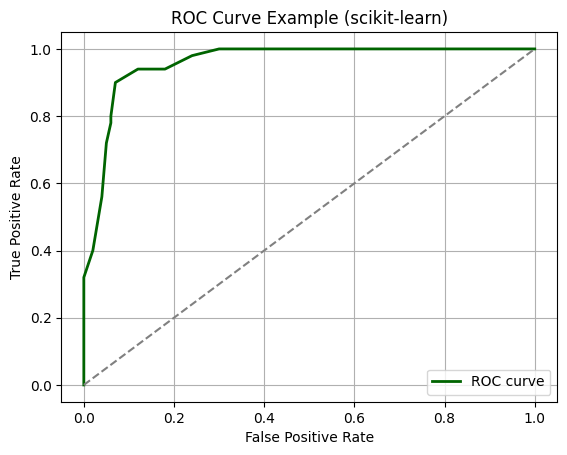

AUC: 0.9586


In [ ]:
# ROC Curve plotting
# scikit-learn's roc_curve is the equivalent of ROCR::performance
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y, iris['pred_proba'])

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkgreen', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Example (scikit-learn)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Calculate and print Area Under Curve (AUC)
roc_auc = sklearn.metrics.auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")